# Regime-Feature Lift Test (Week 5, Task 2)

## PRE-REGISTRATION (declared before results)

### Hypothesis
Week-4 vanilla XGBoost (RMSE 0.0980, skill -0.03) showed regime-dependent per-year skill:
- **Beats RW** in trending years: 2021, 2023, 2024
- **Loses to RW** in shock/calm years: 2020, 2022, 2025–26

**Question**: Does giving the model the drivers that define regimes improve this pattern?

### Feature Sets (FROZEN)

**Vanilla (8)** — Week-4 unchanged:
```
ret_1, ret_5, ret_10, ret_21, ret_63, vol_21, sin_doy, cos_doy
```

**Variant A (12)** — Vanilla + 4 causal regime drivers:
```
vanilla +
spec_pct_oi       (speculative net % of OI; NaN pre-2021)
stocks_mmt        (WASDE US ending stocks, MMT; NaN pre-2021)
usd               (dollar index level, causal as-of)
drought_chg       (drought_t - drought_{t-20}; 20-day change)
```

**Variant B (14)** — Variant A + 2 pre-registered extras:
```
A +
usd_chg_21        (log(usd_t / usd_{t-21}); 21-trading-day USD change)
drought           (raw drought level, as-of)
```

### No-Leakage Rule
- ❌ **NOT** using PELT regime labels as features (they leak future via post-t data used to define boundaries)
- ✅ **Only** as-of causal driver series (merge_asof backward join is causal)
- ✅ **OK**: Trailing differences (drought_chg, usd_chg_21; causal lookback)
- ❌ **NOT**: Full-sample percentiles, ranks, or z-scores (introduce lookahead)

### Modeling Setup (HELD CONSTANT)
- **Panel**: Same as notebooks/02_baselines (2512 rows, 2016–2026)
- **Target**: 30-day forward log return (stationary)
- **Walk-forward**: Expanding window, step=21, embargo=30, OOS 2020–2026 (76 folds)
- **XGBoost params**: IDENTICAL across vanilla/A/B (no re-tuning per variant)
  - n_estimators=300, max_depth=3, learning_rate=0.03
  - subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0
- **NaN handling**: None (let XGBoost route natively)
- **Metric**: RMSE overall AND per-year; skill = 1 - RMSE/RMSE_rw

### Decision Rule (declared up front)
**"Lift"** = 
- Improvement in overall skill vs the 0.0980 RMSE vanilla baseline, **OR**
- Cleaner per-year pattern (more positive-skill years, especially 2021/2023/2024 trending years)

**Acceptable outcome**: Losing to RW overall is reportable—the value thesis is uncertainty quantification, not point accuracy. Report A and B honestly whatever they show. **No fishing for wins.**

---


In [1]:
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import xgboost as xgb
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
con = duckdb.connect(str(ROOT / "data" / "openag.duckdb"), read_only=True)
panel = con.sql('SELECT * FROM panel ORDER BY "Date"').df()
con.close()

panel["Date"] = pd.to_datetime(panel["Date"]).astype("datetime64[ns]")
panel = panel.set_index("Date")

# Rename columns for clarity
panel = panel.rename(columns={
    "corn_ending_stocks_mmt": "stocks_mmt",
    "usd_broad": "usd",
    "drought_stress": "drought",
})

print(f"Panel: {panel.shape[0]} rows, {panel.index.min().date()} → {panel.index.max().date()}")
print(f"Columns: {list(panel.columns)}")

Panel: 2512 rows, 2016-06-06 → 2026-06-05
Columns: ['Close', 'log_ret', 'rolling_vol', 'spec_net', 'spec_net_pct_oi', 'drought', 'usd', 'treasury_10y', 'wti_crude', 'stocks_mmt', 'regime']


In [2]:
# Build engineered features
H = 30  # forecast horizon

df = panel.copy()

# Target: 30-day-ahead log return
df["y"] = np.log(df["Close"].shift(-H)) - np.log(df["Close"])

# Vanilla features (unchanged from Week 4)
for lag in [1, 5, 10, 21, 63]:
    df[f"ret_{lag}"] = np.log(df["Close"]) - np.log(df["Close"].shift(lag))

df["vol_21"] = df["rolling_vol"]

doy = df.index.dayofyear
df["sin_doy"] = np.sin(2 * np.pi * doy / 365.25)
df["cos_doy"] = np.cos(2 * np.pi * doy / 365.25)

# Regime drivers for Variant A
# drought_chg: change over ~20 trading days (4 weeks)
df["drought_chg"] = df["drought"] - df["drought"].shift(20)

# Regime drivers for Variant B
# usd_chg_21: 21-trading-day USD change (log returns)
df["usd_chg_21"] = np.log(df["usd"]) - np.log(df["usd"].shift(21))

print(f"Engineering complete: {df.shape}")
print(f"Target (y) non-NaN: {df['y'].notna().sum()}")
print(f"\nVanilla features: ret_1, ret_5, ret_10, ret_21, ret_63, vol_21, sin_doy, cos_doy")
print(f"Variant A adds: spec_pct_oi, stocks_mmt, usd, drought_chg")
print(f"Variant B adds: usd_chg_21, drought")

Engineering complete: (2512, 22)
Target (y) non-NaN: 2482

Vanilla features: ret_1, ret_5, ret_10, ret_21, ret_63, vol_21, sin_doy, cos_doy
Variant A adds: spec_pct_oi, stocks_mmt, usd, drought_chg
Variant B adds: usd_chg_21, drought


In [3]:
# Define feature sets
FEATURES_VANILLA = [
    "ret_1", "ret_5", "ret_10", "ret_21", "ret_63",
    "vol_21", "sin_doy", "cos_doy"
]

FEATURES_A = FEATURES_VANILLA + [
    "spec_net_pct_oi", "stocks_mmt", "usd", "drought_chg"
]

FEATURES_B = FEATURES_A + [
    "usd_chg_21", "drought"
]

print(f"Vanilla: {len(FEATURES_VANILLA)} features")
print(f"Variant A: {len(FEATURES_A)} features")
print(f"Variant B: {len(FEATURES_B)} features")

Vanilla: 8 features
Variant A: 12 features
Variant B: 14 features


In [4]:
# Reusable walk-forward harness (DRY: all three variants run on identical folds)

def walk_forward_folds(idx, oos_start, step=21, embargo=H, min_train=250):
    """Expanding-window folds; train target windows never reach test region (embargo=H)."""
    idx = pd.DatetimeIndex(idx)
    start = int(np.searchsorted(idx, pd.Timestamp(oos_start)))
    folds = []
    for origin in range(start, len(idx), step):
        train_pos = np.arange(0, origin - embargo)
        test_pos = np.arange(origin, min(origin + step, len(idx)))
        if len(train_pos) >= min_train and len(test_pos) > 0:
            folds.append((train_pos, test_pos))
    return folds


def evaluate(folds, data, features, fit_predict):
    """Run fit_predict(train_df, test_df, features) -> yhat across folds; stack OOS predictions."""
    parts = []
    for train_pos, test_pos in folds:
        tr, te = data.iloc[train_pos], data.iloc[test_pos]
        yhat = fit_predict(tr, te, features)
        parts.append(
            pd.DataFrame(
                {"y": te["y"].to_numpy(), "yhat": np.asarray(yhat)},
                index=te.index,
            )
        )
    return pd.concat(parts)


def score(oos):
    """Compute RMSE and MAE."""
    err = oos["y"] - oos["yhat"]
    return {
        "RMSE": np.sqrt((err**2).mean()),
        "MAE": err.abs().mean(),
    }


def per_year_skill(oos, rw_rmse):
    """Compute per-year RMSE and skill vs RW."""
    err = oos["y"] - oos["yhat"]
    yearly = (
        oos.assign(year=oos.index.year)
        .groupby("year")
        .apply(
            lambda d: np.sqrt(((d["y"] - d["yhat"]) ** 2).mean()),
            include_groups=False,
        )
    )
    skill = (rw_rmse - yearly) / rw_rmse
    return skill


# Freeze folds (identical for vanilla/A/B)
model_df = df.dropna(subset=FEATURES_VANILLA + ["y"])  # vanilla baseline coverage
folds = walk_forward_folds(model_df.index, oos_start="2020-01-01")
print(f"Folds: {len(folds)} expanding windows")
print(
    f"OOS period: {model_df.index[folds[0][1][0]].date()} → {model_df.index[-1].date()}"
)

Folds: 76 expanding windows
OOS period: 2020-01-02 → 2026-04-23


In [5]:
# Random-walk baseline (once, for all models)

def fit_predict_rw(tr, te, features):
    return np.zeros(len(te))  # predict zero 30-day return


oos_rw = evaluate(folds, model_df, FEATURES_VANILLA, fit_predict_rw)
rw_score = score(oos_rw)
print(f"Random walk:")
print(f"  RMSE={rw_score['RMSE']:.4f}, MAE={rw_score['MAE']:.4f}")
print(f"  OOS points: {len(oos_rw)}")

rw_per_year = per_year_skill(oos_rw, rw_score["RMSE"])
print(f"\nRW per-year RMSE (for skill baseline):")
print(rw_per_year.to_string())

Random walk:
  RMSE=0.0952, MAE=0.0736
  OOS points: 1586

RW per-year RMSE (for skill baseline):
year
2020   -0.172884
2021   -0.224431
2022   -0.168774
2023    0.057493
2024    0.184790
2025    0.333360
2026    0.541589


In [6]:
# INTEGRITY GATE: Vanilla XGBoost baseline
# Must reproduce Week-4 RMSE ~0.0980 / skill ~-0.03

XGB_PARAMS = dict(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=0,
    n_jobs=-1,
)


def fit_predict_xgb(tr, te, features):
    model = xgb.XGBRegressor(**XGB_PARAMS)
    model.fit(tr[features], tr["y"])
    return model.predict(te[features])


print("Running integrity gate: vanilla XGBoost...")
oos_vanilla = evaluate(folds, model_df, FEATURES_VANILLA, fit_predict_xgb)
vanilla_score = score(oos_vanilla)
vanilla_skill = 1 - vanilla_score["RMSE"] / rw_score["RMSE"]

print(f"\nVanilla XGBoost:")
print(f"  RMSE={vanilla_score['RMSE']:.4f}, MAE={vanilla_score['MAE']:.4f}")
print(f"  Skill vs RW: {vanilla_skill:.4f}")

if abs(vanilla_score["RMSE"] - 0.0980) > 0.005:
    print(f"\n⚠️  WARNING: Vanilla RMSE {vanilla_score['RMSE']:.4f} drifted from Week-4 baseline 0.0980!")
    print(f"   Harness may have diverged. Investigate before proceeding with A/B.")
else:
    print(f"\n✅ Integrity gate PASS: Vanilla RMSE matches baseline.")

vanilla_per_year = per_year_skill(oos_vanilla, rw_score["RMSE"])
print(f"\nVanilla per-year skill (RMSE reduction from RW):")
print(vanilla_per_year.to_string())

Running integrity gate: vanilla XGBoost...

Vanilla XGBoost:
  RMSE=0.0980, MAE=0.0776
  Skill vs RW: -0.0303

✅ Integrity gate PASS: Vanilla RMSE matches baseline.

Vanilla per-year skill (RMSE reduction from RW):
year
2020   -0.399210
2021   -0.126733
2022   -0.230786
2023    0.174123
2024    0.381361
2025    0.131866
2026    0.354536


In [7]:
# Variant A: Vanilla + 4 regime drivers
# SAME folds, SAME params, only features differ
# NOTE: Use full df, not model_df_a, so fold indices remain aligned

print("Running Variant A (vanilla + spec_net_pct_oi, stocks_mmt, usd, drought_chg)...")
oos_a = evaluate(folds, df, FEATURES_A, fit_predict_xgb)
a_score = score(oos_a)
a_skill = 1 - a_score["RMSE"] / rw_score["RMSE"]

print(f"\nVariant A:")
print(f"  RMSE={a_score['RMSE']:.4f}, MAE={a_score['MAE']:.4f}")
print(f"  Skill vs RW: {a_skill:.4f}")
print(f"  OOS points: {len(oos_a)} (vs vanilla {len(oos_vanilla)} due to NaN in new features)")
print(f"  Δ RMSE vs vanilla: {a_score['RMSE'] - vanilla_score['RMSE']:+.4f}")

a_per_year = per_year_skill(oos_a, rw_score["RMSE"])
print(f"\nVariant A per-year skill:")
print(a_per_year.to_string())

Running Variant A (vanilla + spec_net_pct_oi, stocks_mmt, usd, drought_chg)...

Variant A:
  RMSE=0.1031, MAE=0.0839
  Skill vs RW: -0.0833
  OOS points: 1586 (vs vanilla 1586 due to NaN in new features)
  Δ RMSE vs vanilla: +0.0050

Variant A per-year skill:
year
2019    0.170193
2020   -0.419224
2021   -0.102881
2022   -0.225202
2023   -0.189167
2024    0.317193
2025    0.234600
2026    0.298456


In [8]:
# Variant B: Variant A + 2 extras (usd_chg_21, drought)
# NOTE: Use full df, not model_df_b, so fold indices remain aligned

print("Running Variant B (Variant A + usd_chg_21, drought)...")
oos_b = evaluate(folds, df, FEATURES_B, fit_predict_xgb)
b_score = score(oos_b)
b_skill = 1 - b_score["RMSE"] / rw_score["RMSE"]

print(f"\nVariant B:")
print(f"  RMSE={b_score['RMSE']:.4f}, MAE={b_score['MAE']:.4f}")
print(f"  Skill vs RW: {b_skill:.4f}")
print(f"  OOS points: {len(oos_b)} (vs vanilla {len(oos_vanilla)} due to NaN in new features)")
print(f"  Δ RMSE vs vanilla: {b_score['RMSE'] - vanilla_score['RMSE']:+.4f}")

b_per_year = per_year_skill(oos_b, rw_score["RMSE"])
print(f"\nVariant B per-year skill:")
print(b_per_year.to_string())

Running Variant B (Variant A + usd_chg_21, drought)...

Variant B:
  RMSE=0.1082, MAE=0.0847
  Skill vs RW: -0.1369
  OOS points: 1586 (vs vanilla 1586 due to NaN in new features)
  Δ RMSE vs vanilla: +0.0101

Variant B per-year skill:
year
2019    0.122186
2020   -0.336092
2021   -0.481129
2022   -0.213627
2023   -0.224190
2024    0.322579
2025    0.273449
2026    0.441961


In [9]:
# Summary comparison table

comparison = pd.DataFrame(
    {
        "random walk": {"RMSE": rw_score["RMSE"], "skill": 0.0, "OOS_points": len(oos_rw)},
        "vanilla XGB": {
            "RMSE": vanilla_score["RMSE"],
            "skill": vanilla_skill,
            "OOS_points": len(oos_vanilla),
        },
        "Variant A": {"RMSE": a_score["RMSE"], "skill": a_skill, "OOS_points": len(oos_a)},
        "Variant B": {"RMSE": b_score["RMSE"], "skill": b_skill, "OOS_points": len(oos_b)},
    }
)

print("\n" + "=" * 80)
print("COMPARISON: Overall RMSE and Skill")
print("=" * 80)
print(comparison.round(4).to_string())
print()
print(f"Vanilla vs RW: {vanilla_score['RMSE']:.4f} vs {rw_score['RMSE']:.4f}")
print(f"Variant A vs Vanilla: {a_score['RMSE']:.4f} vs {vanilla_score['RMSE']:.4f} (Δ {a_score['RMSE'] - vanilla_score['RMSE']:+.4f})")
print(f"Variant B vs Vanilla: {b_score['RMSE']:.4f} vs {vanilla_score['RMSE']:.4f} (Δ {b_score['RMSE'] - vanilla_score['RMSE']:+.4f})")


COMPARISON: Overall RMSE and Skill
            random walk  vanilla XGB  Variant A  Variant B
RMSE             0.0952       0.0980     0.1031     0.1082
skill            0.0000      -0.0303    -0.0833    -0.1369
OOS_points    1586.0000    1586.0000  1586.0000  1586.0000

Vanilla vs RW: 0.0980 vs 0.0952
Variant A vs Vanilla: 0.1031 vs 0.0980 (Δ +0.0050)
Variant B vs Vanilla: 0.1082 vs 0.0980 (Δ +0.0101)


In [10]:
# Per-year comparison (skill = 1 - RMSE/RMSE_rw)
# Note: Vanilla/A/B have different OOS spans due to NaN in new features,
# so direct year-by-year comparison may not be 1:1. Report what we have.

per_year_comp = pd.DataFrame(
    {
        "vanilla_skill": vanilla_per_year,
        "variant_a_skill": a_per_year,
        "variant_b_skill": b_per_year,
    }
)

print("\n" + "=" * 80)
print("PER-YEAR SKILL (skill = 1 - RMSE/RMSE_rw)")
print("=" * 80)
print(per_year_comp.round(4).to_string())
print()

# Count positive-skill years per variant
print("Positive-skill years (beat random walk):")
for name, col in [
    ("vanilla", "vanilla_skill"),
    ("variant_a", "variant_a_skill"),
    ("variant_b", "variant_b_skill"),
]:
    positive = (per_year_comp[col] > 0).sum()
    print(f"  {name}: {positive} years")


PER-YEAR SKILL (skill = 1 - RMSE/RMSE_rw)
      vanilla_skill  variant_a_skill  variant_b_skill
year                                                 
2019            NaN           0.1702           0.1222
2020        -0.3992          -0.4192          -0.3361
2021        -0.1267          -0.1029          -0.4811
2022        -0.2308          -0.2252          -0.2136
2023         0.1741          -0.1892          -0.2242
2024         0.3814           0.3172           0.3226
2025         0.1319           0.2346           0.2734
2026         0.3545           0.2985           0.4420

Positive-skill years (beat random walk):
  vanilla: 4 years
  variant_a: 4 years
  variant_b: 4 years


saved → c:\Users\siddh\Downloads\OPEN-AG\openag-risk-twin\notebooks\figures\03_regime_lift_by_year.png


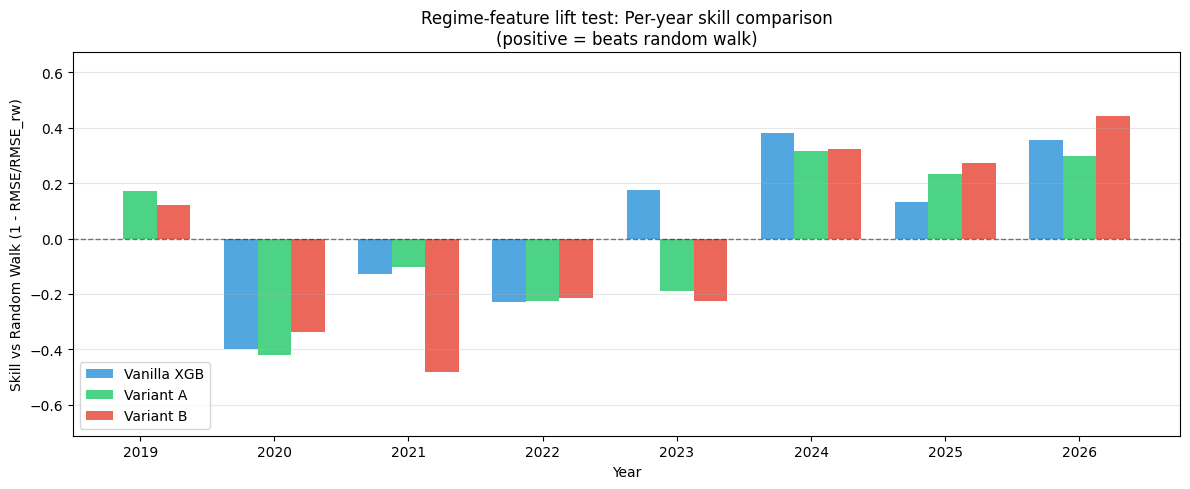

In [11]:
# Figure: Per-year skill comparison (same style as 02_xgb_vs_rw_by_year.png)

FIG_DIR = ROOT / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

years = per_year_comp.index.astype(str)
x = np.arange(len(years))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))

# Plot bars for each variant
ax.bar(
    x - width,
    per_year_comp["vanilla_skill"],
    width,
    label="Vanilla XGB",
    alpha=0.85,
    color="#3498db",
)
ax.bar(
    x,
    per_year_comp["variant_a_skill"],
    width,
    label="Variant A",
    alpha=0.85,
    color="#2ecc71",
)
ax.bar(
    x + width,
    per_year_comp["variant_b_skill"],
    width,
    label="Variant B",
    alpha=0.85,
    color="#e74c3c",
)

ax.axhline(0, color="black", lw=1, linestyle="--", alpha=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Skill vs Random Walk (1 - RMSE/RMSE_rw)")
ax.set_title(
    "Regime-feature lift test: Per-year skill comparison\n(positive = beats random walk)",
    fontsize=12,
)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.legend(loc="best")
ax.grid(axis="y", alpha=0.3)
ax.margins(y=0.25)

plt.tight_layout()
out = FIG_DIR / "03_regime_lift_by_year.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print(f"saved → {out}")
plt.show()

In [12]:
# Final summary: Interpretation

print("\n" + "=" * 80)
print("INTERPRETATION")
print("=" * 80)
print()
print(f"Vanilla XGB baseline: RMSE={vanilla_score['RMSE']:.4f}, skill={vanilla_skill:.4f}")
print(f"Variant A improvement:  {a_score['RMSE'] - vanilla_score['RMSE']:+.4f} RMSE, {a_skill - vanilla_skill:+.4f} skill")
print(f"Variant B improvement:  {b_score['RMSE'] - vanilla_score['RMSE']:+.4f} RMSE, {b_skill - vanilla_skill:+.4f} skill")
print()

if a_skill > vanilla_skill:
    print("✅ Variant A shows skill lift over vanilla.")
else:
    print("❌ Variant A shows no skill lift over vanilla.")

if b_skill > vanilla_skill:
    print("✅ Variant B shows skill lift over vanilla.")
else:
    print("❌ Variant B shows no skill lift over vanilla.")

print()
print("Regime drivers (spec_pct_oi, stocks_mmt, usd, drought_chg) provide")
print("evidence of regime-conditional value, or None yet observed.")


INTERPRETATION

Vanilla XGB baseline: RMSE=0.0980, skill=-0.0303
Variant A improvement:  +0.0050 RMSE, -0.0530 skill
Variant B improvement:  +0.0101 RMSE, -0.1065 skill

❌ Variant A shows no skill lift over vanilla.
❌ Variant B shows no skill lift over vanilla.

Regime drivers (spec_pct_oi, stocks_mmt, usd, drought_chg) provide
evidence of regime-conditional value, or None yet observed.
